## K-Means

In [2]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor,XGBClassifier
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score
import numpy as np
pd.set_option('display.max_rows', 100)    
pd.set_option('display.max_columns', 50) 

In [3]:
data = pd.read_csv("./dataset/employee.csv")

In [80]:
df = pd.read_csv("./dataset/employee.csv")

### Data Cleaning

In [77]:
data.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,Education,EducationField,JobRole,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,275,Leonelle,Simco,0,30,2,1,27,1,6,5,5,9,0,102059,1,0,2012-01-03,No,10,4,9,7
1,1158,Leonerd,Aland,1,38,2,1,23,0,6,4,5,9,2,157718,0,1,2012-01-04,No,10,6,10,0
2,842,Ahmed,Sykes,1,43,2,0,29,0,1,4,6,3,1,309964,1,0,2012-01-04,No,10,6,10,8
3,402,Ermentrude,Berrie,2,39,2,2,12,1,6,3,1,2,1,293132,0,0,2012-01-05,No,10,10,10,0
4,369,Stace,Savege,0,29,2,0,29,0,6,2,8,8,2,49606,0,0,2012-01-05,Yes,6,1,1,6


In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   EmployeeID               1470 non-null   int64         
 1   FirstName                1470 non-null   object        
 2   LastName                 1470 non-null   object        
 3   Gender                   1470 non-null   int64         
 4   Age                      1470 non-null   int64         
 5   BusinessTravel           1470 non-null   int64         
 6   Department               1470 non-null   int64         
 7   DistanceFromHome (KM)    1470 non-null   int64         
 8   State                    1470 non-null   int64         
 9   Ethnicity                1470 non-null   int64         
 10  Education                1470 non-null   int64         
 11  EducationField           1470 non-null   int64         
 12  JobRole                  1470 non-

In [47]:
emp_id = LabelEncoder()
data["EmployeeID"] = emp_id.fit_transform(data["EmployeeID"])

In [55]:
data["EmployeeID"] = data["EmployeeID"].astype("int64")

In [48]:
gend = LabelEncoder()
data["Gender"] = gend.fit_transform(data["Gender"])

In [50]:
data["BusinessTravel"].unique()

array(['Some Travel', 'No Travel ', 'Frequent Traveller'], dtype=object)

In [51]:
b_trav = LabelEncoder()
data["BusinessTravel"] = b_trav.fit_transform(data["BusinessTravel"])

In [53]:
dep = LabelEncoder()
data["Department"] = dep.fit_transform(data["Department"])

In [57]:
stat = LabelEncoder()
data["State"] = stat.fit_transform(data["State"])

In [60]:
eth = LabelEncoder()
data["Ethnicity"] = eth.fit_transform(data["Ethnicity"])

In [63]:
field = LabelEncoder()
data["EducationField"] = field.fit_transform(data["EducationField"])

In [66]:
rol = LabelEncoder()
data["JobRole"] = rol.fit_transform(data["JobRole"])

In [69]:
mart = LabelEncoder()
data["MaritalStatus"] = stat.fit_transform(data["MaritalStatus"])

In [72]:
over = LabelEncoder()
data["OverTime"] = stat.fit_transform(data["OverTime"])

In [75]:
data["HireDate"] = data["HireDate"].astype("datetime64[ns]")

In [78]:
attr = LabelEncoder()
data["Attrition"] = attr.fit_transform(data["Attrition"])

In [97]:
df.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,Education,EducationField,JobRole,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,5,Marketing,Sales Executive,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,4,Marketing,Sales Executive,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,4,Marketing,HR Business Partner,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,3,Computer Science,Engineering Manager,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,2,Technical Degree,Recruiter,Single,49606,0,No,2012-01-05,Yes,6,1,1,6


In [82]:
data.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,Education,EducationField,JobRole,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,275,Leonelle,Simco,0,30,2,1,27,1,6,5,5,9,0,102059,1,0,2012-01-03,0,10,4,9,7
1,1158,Leonerd,Aland,1,38,2,1,23,0,6,4,5,9,2,157718,0,1,2012-01-04,0,10,6,10,0
2,842,Ahmed,Sykes,1,43,2,0,29,0,1,4,6,3,1,309964,1,0,2012-01-04,0,10,6,10,8
3,402,Ermentrude,Berrie,2,39,2,2,12,1,6,3,1,2,1,293132,0,0,2012-01-05,0,10,10,10,0
4,369,Stace,Savege,0,29,2,0,29,0,6,2,8,8,2,49606,0,0,2012-01-05,1,6,1,1,6


<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

### Visual Analysis of Data

<Axes: >

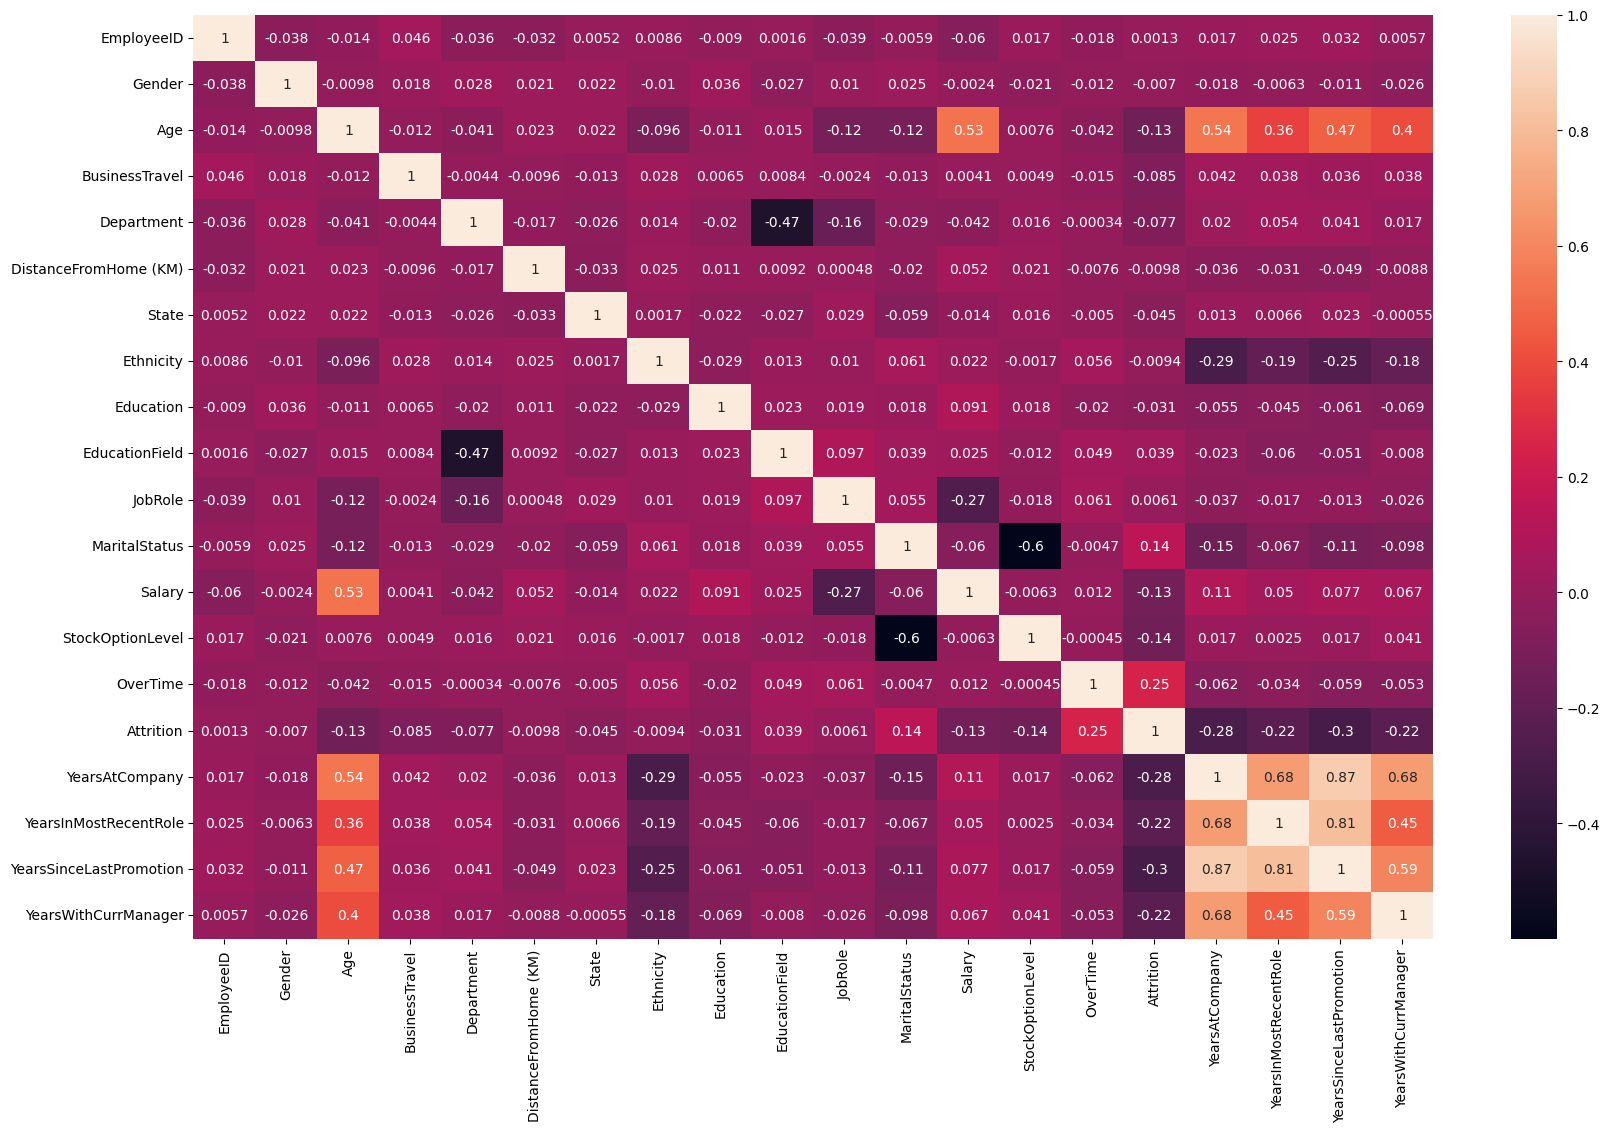

In [90]:
plt.figure(figsize=(20, 12))
correlated = data.corr(numeric_only = True)
sns.heatmap(data = correlated,annot = True)

<Axes: xlabel='Age', ylabel='Salary'>

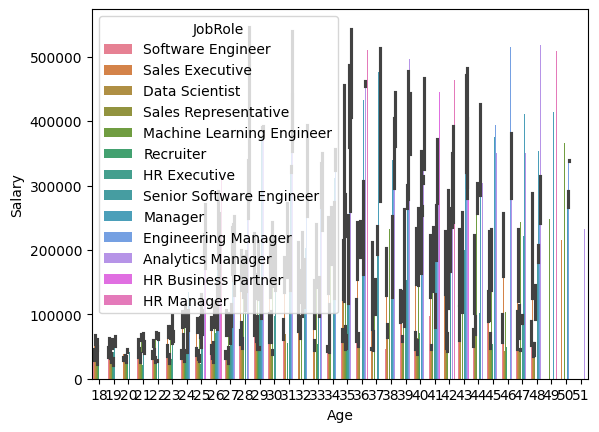

In [98]:
sns.barplot(y = "Salary",x="Age",hue="JobRole",data = df)

<Axes: xlabel='JobRole', ylabel='Salary'>

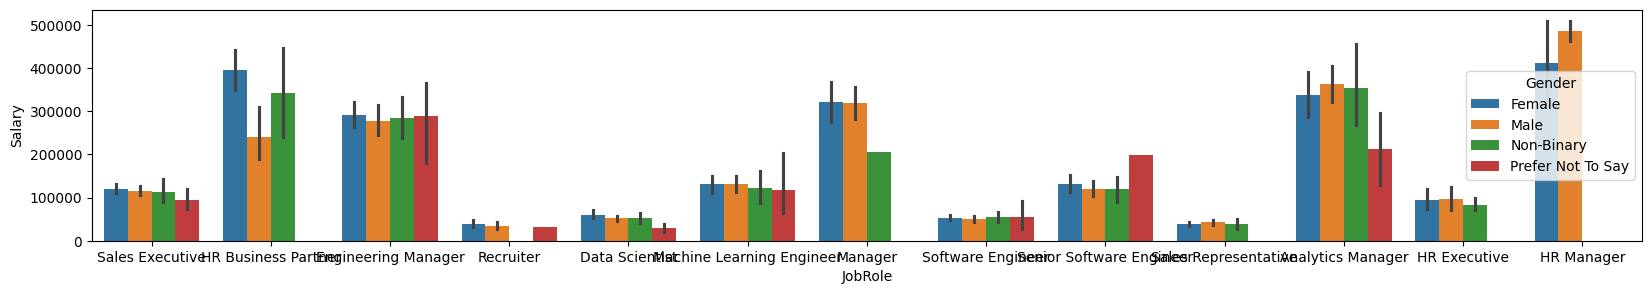

In [106]:
plt.figure(figsize=(20, 3))
sns.barplot(y = "Salary",x="JobRole",data = df,hue = "Gender")

<Axes: xlabel='Age', ylabel='Salary'>

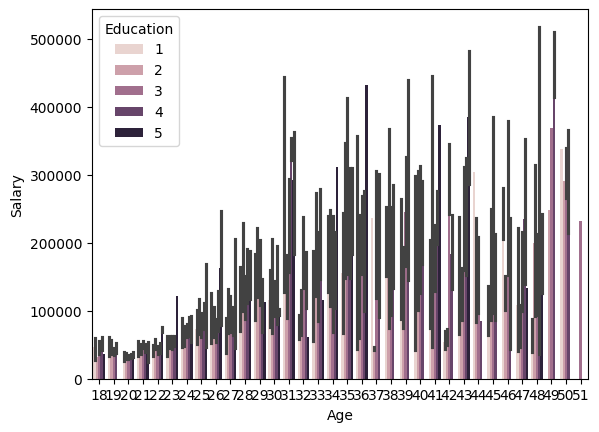

In [96]:
sns.barplot(y = "Salary",x="Age",hue="Education",data = df)

<Axes: xlabel='OverTime', ylabel='Salary'>

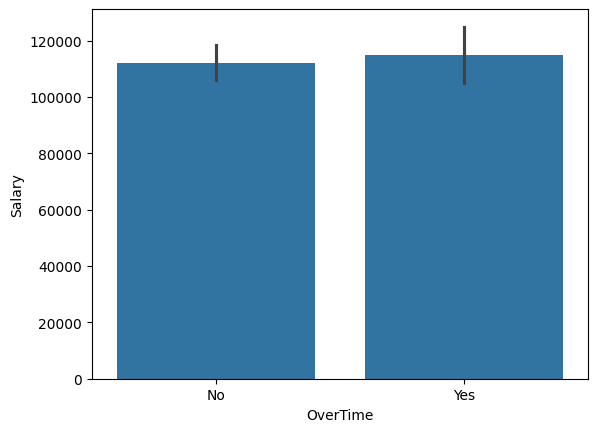

In [112]:
sns.barplot(y = "Salary",x="OverTime",data = df)

<Axes: xlabel='YearsAtCompany', ylabel='Salary'>

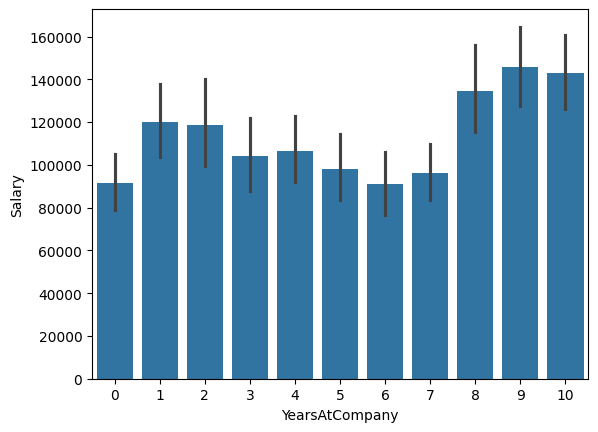

In [113]:
sns.barplot(y = "Salary",x="YearsAtCompany",data = df)

## Salary Prediction 

In [92]:
data.columns

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus',
       'Salary', 'StockOptionLevel', 'OverTime', 'HireDate', 'Attrition',
       'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [244]:
x = data[["Department","Education","JobRole","State","Gender","Age"]]
y = data["Salary"]

In [245]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

In [274]:
salary_prediction = XGBRegressor(n_estimators=16)

In [275]:
salary_prediction.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=16,
             n_jobs=None, num_parallel_tree=None, ...)

In [276]:
y_pred = salary_prediction.predict(x_test)

In [277]:
y_train_pred = salary_prediction.predict(x_train)

In [278]:
r2_train= r2_score(y_train,y_train_pred)
print(f"r2 score Train = {r2_train*100}")

r2 score Train = 87.4818503856659


In [279]:
r2= r2_score(y_test,y_pred)
print(f"r2 score  = {r2*100}")

r2 score  = 80.72226047515869


In [280]:
mse = mean_squared_error(y_test,y_pred)
print("mean squared Error : ",mse)

mean squared Error :  2774954240.0


In [281]:
r2_scores = []
mse_scores = []

for n in range(1, 201):
    model = XGBRegressor(n_estimators=n, random_state=42)
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    r2_scores.append(r2)
    mse_scores.append(mse)

In [282]:
best_n_r2 = np.argmax(r2_scores) + 1
best_n_mse = np.argmin(mse_scores) + 1

In [286]:
r2_scores[best_n_r2]

0.8072226047515869

In [285]:
mse_scores[best_n_r2]

2774954240.0

In [287]:
best_n_r2

np.int64(15)

## Departement Predictor

In [288]:
x = data[["Education","JobRole","State","Gender","Age","EducationField"]]
y = data["Department"]

In [290]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

In [289]:
model = XGBRegressor(n_estimators=16)

In [293]:
accuracy = []

for n in range(1, 201):
    model = XGBClassifier(n_estimators=n, random_state=42)
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    
    accur = accuracy_score(y_test, y_pred)
    
    accuracy.append(accur)

In [294]:
b_accuracy =np.argmax(accuracy) + 1
accuracy[b_accuracy]

1.0

In [295]:
b_accuracy

np.int64(1)

In [6]:
data["Department"].unique()

array(['Sales', 'Human Resources', 'Technology'], dtype=object)